# Bayesian Model Mixing using Gaussian Processes: Stationary Kernel Tutorial

## Author: Alexandra C. Semposki

### Date: 05 May 2026

Welcome to the tutorial notebook for using the new `gp-bmm` method in `Taweret`! Here we will overview what the method does and how to use it on a toy model. This tutorial specifically handles the so-called "stationary" kernel, which uses the Euclidean distance between points in the input space as the main input to the kernel. In the next notebook, we will cover the scenario where this assumption is not sufficient and we need to include structure from the input space in our kernel construction. 

Below, we set up the toy model that we will be using, the so-called "SAMBA models", and then construct a stationary, squared-exponential radial basis function (RBF) kernel that will be used to mix the two models we have chosen. We will also cover the inclusion of a hyperprior on the hyperparameters of this kernel, so that we obtain better physically-motivated results, which will be extremely useful for realistic physics applications.

The core of this work was included in `Taweret` from [this paper](https://arxiv.org/abs/2505.18921) and [this paper](https://arxiv.org/abs/2505.18921), written by A. C. Semposki et al., and the accompanying package, `neutron-rich-bmm`, originally found [here](https://github.com/asemposki/neutron-rich-bmm). 

In [103]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
# load the proper location in Taweret for this case
import sys
sys.path.append('../../../src/Taweret')
from Taweret.models.samba_models import *
from mix.gp_bmm import *

We need to define the models we would like to perform model mixing on. These are contained in the `Taweret` models folder. 

In [105]:
# now we write out the models we need
orders=[3,4]
model_1 = Loworder(order=orders[0])
model_2 = Highorder(order=orders[1])

# make the model dict
models = {
    "1": model_1,
    "2": model_2
}

print(models, type(models))

{'1': <Taweret.models.samba_models.Loworder object at 0x11c3ddcd0>, '2': <Taweret.models.samba_models.Highorder object at 0x11ae58a10>} <class 'dict'>


Once these models have been initialized, we need to evaluate their results before we have applied any model mixing strategy. This is done below.

In [106]:
#predict functions for the plot
g = np.linspace(1e-6, 1.0, 100)
predict = []

for i in models.keys():
    predict.append(models[i].evaluate(g))

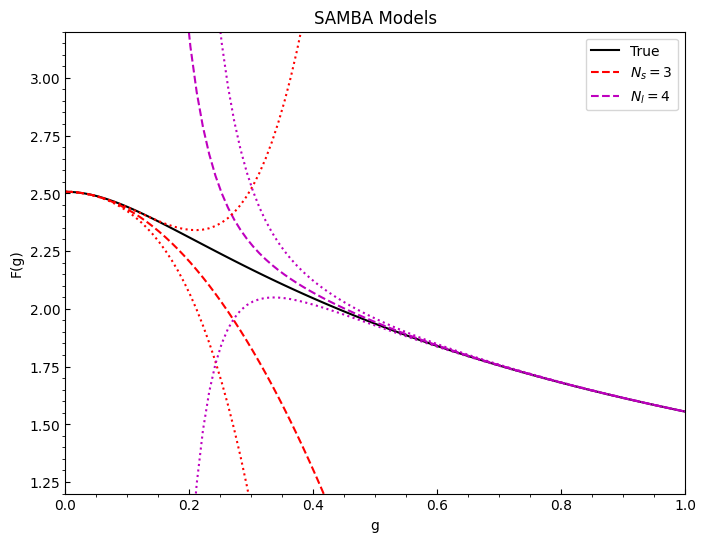

In [107]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

ax.legend()

Because the method we wish to use, the GP-BMM strategy, requires that we possess not only means and standard deviations at each data point from the models, but also the covariance matrix of the model at those points, we will construct a toy covariance matrix for both models. In reality, this information should hopefully already be present in the physics model. If it is not, one can do an estimation of this like below to try to emulate the expected covariance.

In [108]:
def build_cov_from_errors(x, sigma, ell=10.0, nugget=1e-6):
    x = np.asarray(x)
    sigma = np.asarray(sigma)

    dx = x[:, None] - x[None, :]
    rho = np.exp(-0.5 * (dx / ell)**2)

    C = np.outer(sigma, sigma) * rho
    C += nugget * np.eye(len(x))
    return C

# take some training data from these, and make some covariances up for the toy case
x1 = g[:30:5]
x2 = np.append(g[40:-1:5], g[-1])

# cut the data as well
data1 = predict[0][0][:30:5]
sigma1 = predict[0][1][:30:5]
data2 = np.append(predict[1][0][40:-1:5], predict[1][0][-1])
sigma2 = np.append(predict[1][1][40:-1:5], predict[1][1][-1])

# try the covariance function here
cov1 = build_cov_from_errors(x1, sigma1, ell=0.1, nugget=1e-6)
cov2 = build_cov_from_errors(x2, sigma2, ell=1.0, nugget=1e-6)

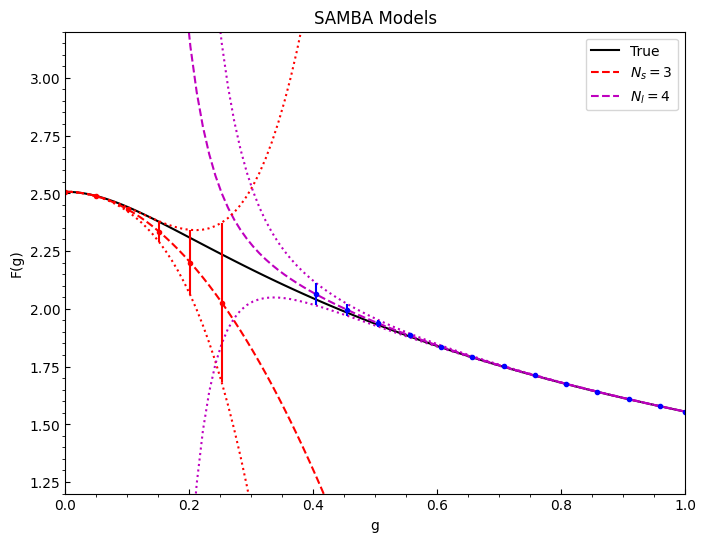

In [109]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

ax.legend()
plt.show()

In [110]:
# concatenate the training data
from scipy.linalg import block_diag
x_train = np.concatenate((x1, x2)).reshape(-1,1)
y_train = np.concatenate((data1,data2)).reshape(-1,1)

# covariance matrix
alpha = block_diag(cov1, cov2)

Now we have our training data, so let's try to construct a valid *stationary* GP for this problem that is able to capture the underlying truth. We begin by choosing the default priors that the mixing class already contains.

In [111]:
# now we make a kernel to send to the class using typical scikit-learn notation
kernel = C(constant_value=1.1, constant_value_bounds=[0.25,2.25]) * RBF(length_scale=0.05, length_scale_bounds=[0.02,0.1])

With the kernel defined for the GP, we then call the mixing method from the `Taweret` mixing folder; this is called the `GPmixing` class.

In [112]:
# load the class for mixing with no prior assumptions
bmm = GPmixing(g, models=models, alpha=alpha, kernel=kernel, priors=True, prior_params=None, prior_choice='rbfnorm')

In [113]:
# try looking at the unconstrained prior
unconstrained_prior = bmm.prior_predict()

In the above, we notice that the mean is zero. This is because we haven't actually conditioned the GP on the training data, so it has no information about the data yet. We've simply calculated what the prior might give us across the regime given the kernel we have defined. Hence, it is often better to return the draws from this distribution, since they will show us the spread of the prior better than these quantities will. We do this below and plot the draws.

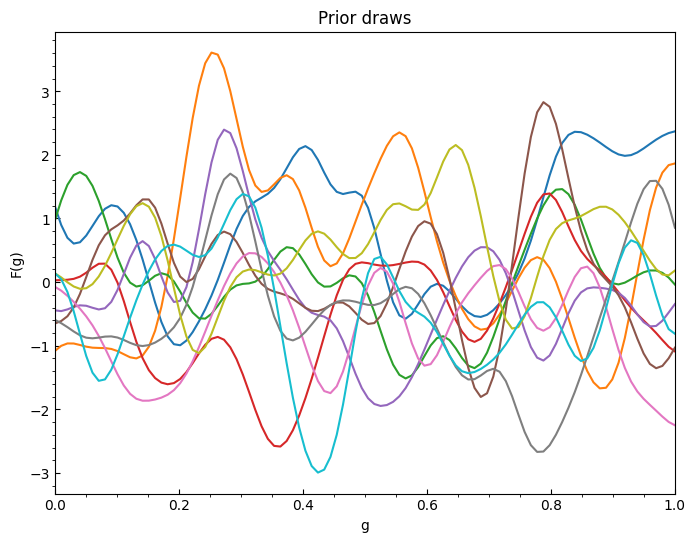

In [114]:
# draw from the prior
_, draws = bmm.prior_predict(sample=True, n_samples=10)

#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('Prior draws')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')
ax.plot(g, draws)
plt.show()

We can also evaluate the prior using the evaluate function, which is still occurring before any training has happened. This is done below.

In [115]:
evalprior = bmm.evaluate(x_train)

Then we can train the hyperparameters of the GP kernel, and produce our BMM result. We do this by using the `train` function in the `GPMixing` class.

In [116]:
# train the GP using the train function
bmm.train(x_train, y_train)

In [117]:
print('Initial kernel:', bmm.gpr.kernel)
print('Trained kernel:', bmm.gpr.kernel_)

Initial kernel: 1.05**2 * RBF(length_scale=0.05)
Trained kernel: 0.983**2 * RBF(length_scale=0.0994)


We can see that the values have indeed changed, so the calibration of these parameters is working. We note that, since we did not choose any prior for our hyperparameters, but asked for priors to be applied via `priors=True` in our class definition, we have used the default priors of the `Taweret` code to obtain this result. These are shown below.

In [118]:
# reveal default priors
print(bmm.prior_params)

{'sigma': {'mu': 1.0, 'sig': 0.25}, 'lengthscale': {'mu': 1.0, 'sig': 0.15}}


Now that the training has been completed, let's look at the predictions from this result. We plot them over the original models for comparison.

In [119]:
# let's predict with this kernel now
predictions = bmm.predict()

# check the keys of the dict
print(predictions.keys())

dict_keys(['x', 'mean', 'std', 'cov'])


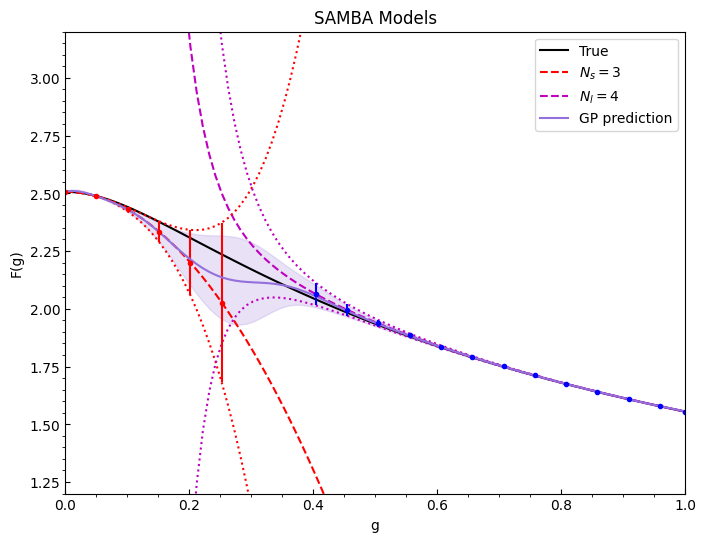

In [120]:
# plot these results over the original models and the data
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# GP results
ax.plot(predictions['x'], predictions['mean'], color='mediumpurple', label='GP prediction')
ax.fill_between(predictions['x'], predictions['mean']-predictions['std'],
                predictions['mean']+predictions['std'], color='mediumpurple', alpha=0.2)

ax.legend()
plt.show()

In [121]:
print('Optimized parameters:', bmm.map)

Optimized parameters: [0.96566598 0.09935728]


Now we test using different prior definitions instead of the default parameters; this for now doesn't mean we choose a different prior **form**, rather, we change our mean and variance values of the truncated Gaussian that is being used under the hood here. However, this is a change that can also be made---priors can be given to `Taweret` by the user through generating and including a priors.py file in the `utils` folder. There is already a blank template there for new users to get started.

For now, to simply change the values of the hyperprior forms, e.g., the mean and variance, we need to define the priors we wish to choose here, or we can use the default prior settings incorporated into `Taweret`.

In [122]:
prior_params = {
                    'sigma': {'mu': 1.0, 'sig': 0.25},
                    'lengthscale': {'mu': 0.1, 'sig': 0.05}
                }

In [123]:
# try running this code with input prior params dicts
bmm2 = GPmixing(g, models=models, alpha=alpha, kernel=kernel, priors=True, prior_params=prior_params, prior_choice='rbfnorm')

In [124]:
bmm2.train(x_train, y_train)

In [125]:
predictionspriors = bmm2.predict()

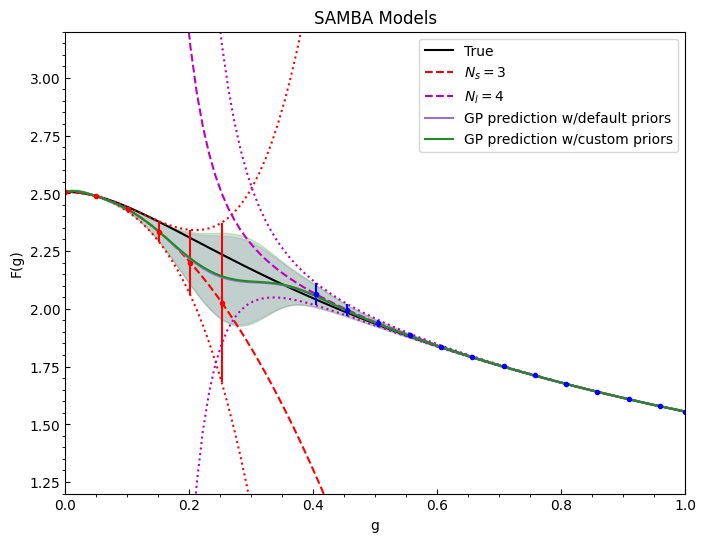

In [126]:
# plot these results over the original models and the data
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# GP results
ax.plot(predictions['x'], predictions['mean'], color='mediumpurple', label='GP prediction w/default priors')
ax.fill_between(predictions['x'], predictions['mean']-predictions['std'],
                predictions['mean']+predictions['std'], color='mediumpurple', alpha=0.2)

ax.plot(predictionspriors['x'], predictionspriors['mean'], color='forestgreen', label='GP prediction w/custom priors')
ax.fill_between(predictionspriors['x'], predictionspriors['mean']-predictionspriors['std'],
                predictionspriors['mean']+predictionspriors['std'], color='forestgreen', alpha=0.2)

ax.legend()
plt.show()

We can see above the slight difference between this model and the one we trained using the default priors recommended. One can continue to play with the possibilities to determine which constraints are most physically meaningful for the problem at hand. For now, we hope this tutorial helped you get used to the capabilities of the `GPMixing` module in `Taweret`!